# F1 Strategy – Data Exploration
**Task:** Binary classification — predict `PitNextLap` (will the driver pit on the next lap?).

**Data path:** `/media/oscarm524/Expansion/Kaggle/2026/PS_Ep5/Data/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR = "/media/oscarm524/Expansion/Kaggle/2026/PS_Ep5/Data/"

train = pd.read_csv(DATA_DIR + "train.csv")
orig  = pd.read_csv(DATA_DIR + "f1_strategy_dataset_v4.csv")

print("train shape :", train.shape)
print("orig  shape :", orig.shape)

/home/oscarm524/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


train shape : (439140, 16)
orig  shape : (101371, 16)


## 1. Basic Overview

In [2]:
print("=== Columns ===")
print(train.columns.tolist())
print("\n=== Data Types ===")
print(train.dtypes)
print("\n=== First 5 rows ===")
train.head()

=== Columns ===
['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']

=== Data Types ===
id                          int64
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object

=== First 5 rows ===


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [3]:
print("=== Missing Values ===")
missing = train.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values in train.csv")

print("\n=== Descriptive Statistics ===")
train.describe()

=== Missing Values ===
No missing values in train.csv

=== Descriptive Statistics ===


,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


## 2. Target Variable — `PitNextLap`

Class counts:
PitNextLap
0 – No pit    351759
1 – Pit        87381
Name: count, dtype: int64

Class percentages:
PitNextLap
0 – No pit    80.1 %
1 – Pit       19.9 %
Name: proportion, dtype: object


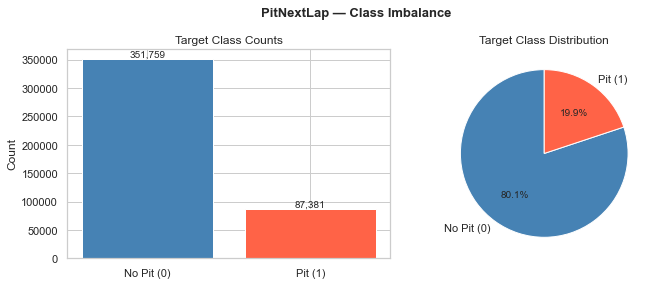


Imbalance ratio (0:1) = 4.03x


In [4]:
target_counts = train["PitNextLap"].value_counts()
target_pct    = train["PitNextLap"].value_counts(normalize=True) * 100

print("Class counts:")
print(target_counts.rename({0.0: "0 – No pit", 1.0: "1 – Pit"}))
print("\nClass percentages:")
print(target_pct.rename({0.0: "0 – No pit", 1.0: "1 – Pit"}).round(2).astype(str) + " %")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(["No Pit (0)", "Pit (1)"], target_counts.values,
            color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Target Class Counts")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3000,
                 f"{val:,}", ha="center", fontsize=10)

# Pie chart
axes[1].pie(target_counts.values, labels=["No Pit (0)", "Pit (1)"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"],
            startangle=90, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Target Class Distribution")

plt.suptitle("PitNextLap — Class Imbalance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

imbalance_ratio = target_counts[0.0] / target_counts[1.0]
print(f"\nImbalance ratio (0:1) = {imbalance_ratio:.2f}x")

## 3. Categorical Feature Distributions

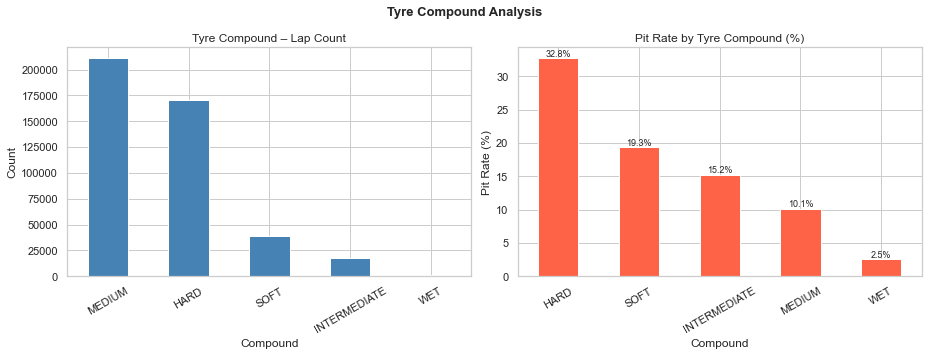

In [5]:
# Tyre Compound distribution & pit rate
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

compound_counts = train["Compound"].value_counts()
compound_pit_rate = train.groupby("Compound")["PitNextLap"].mean() * 100

compound_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Tyre Compound – Lap Count")
axes[0].set_xlabel("Compound")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

compound_pit_rate.sort_values(ascending=False).plot(kind="bar", ax=axes[1],
    color="tomato", edgecolor="white")
axes[1].set_title("Pit Rate by Tyre Compound (%)")
axes[1].set_xlabel("Compound")
axes[1].set_ylabel("Pit Rate (%)")
axes[1].tick_params(axis="x", rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                     ha="center", fontsize=9)

plt.suptitle("Tyre Compound Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

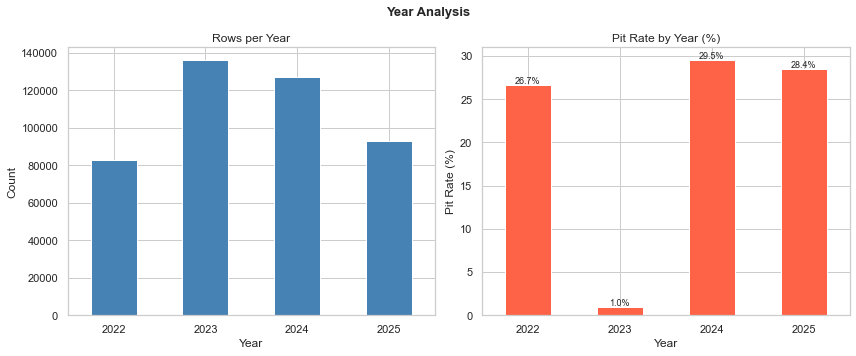

In [6]:
# Year distribution & pit rate
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

year_counts   = train["Year"].value_counts().sort_index()
year_pit_rate = train.groupby("Year")["PitNextLap"].mean() * 100

year_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Rows per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

year_pit_rate.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("Pit Rate by Year (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Pit Rate (%)")
axes[1].tick_params(axis="x", rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.2),
                     ha="center", fontsize=9)

plt.suptitle("Year Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

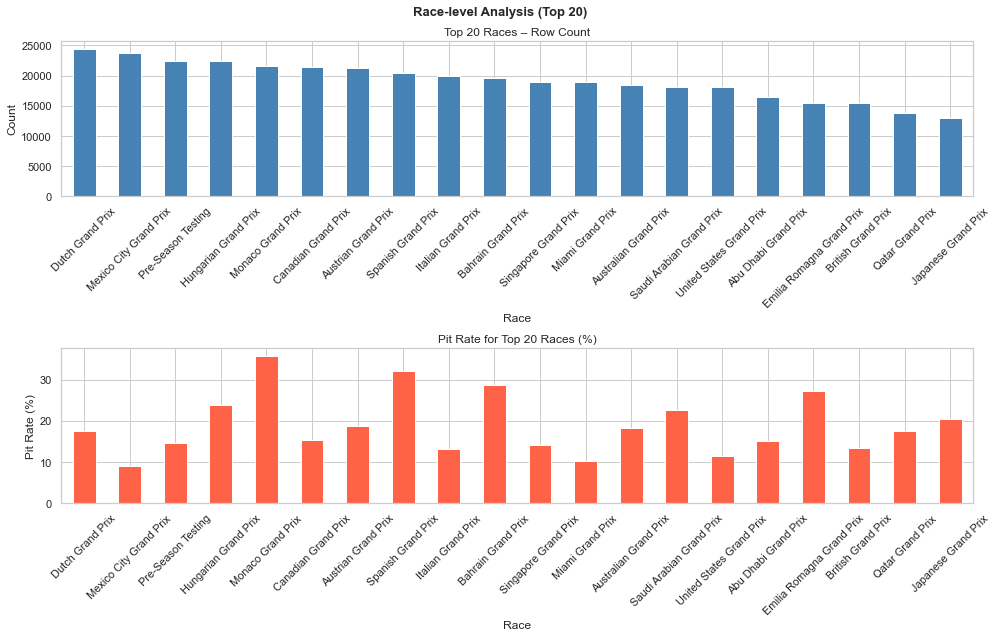

In [7]:
# Top 20 Races by row count + pit rate
top_races     = train["Race"].value_counts().head(20)
race_pit_rate = train.groupby("Race")["PitNextLap"].mean() * 100
race_pit_rate = race_pit_rate.loc[top_races.index]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

top_races.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Top 20 Races – Row Count")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

race_pit_rate.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("Pit Rate for Top 20 Races (%)")
axes[1].set_ylabel("Pit Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Race-level Analysis (Top 20)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Numeric Feature Distributions

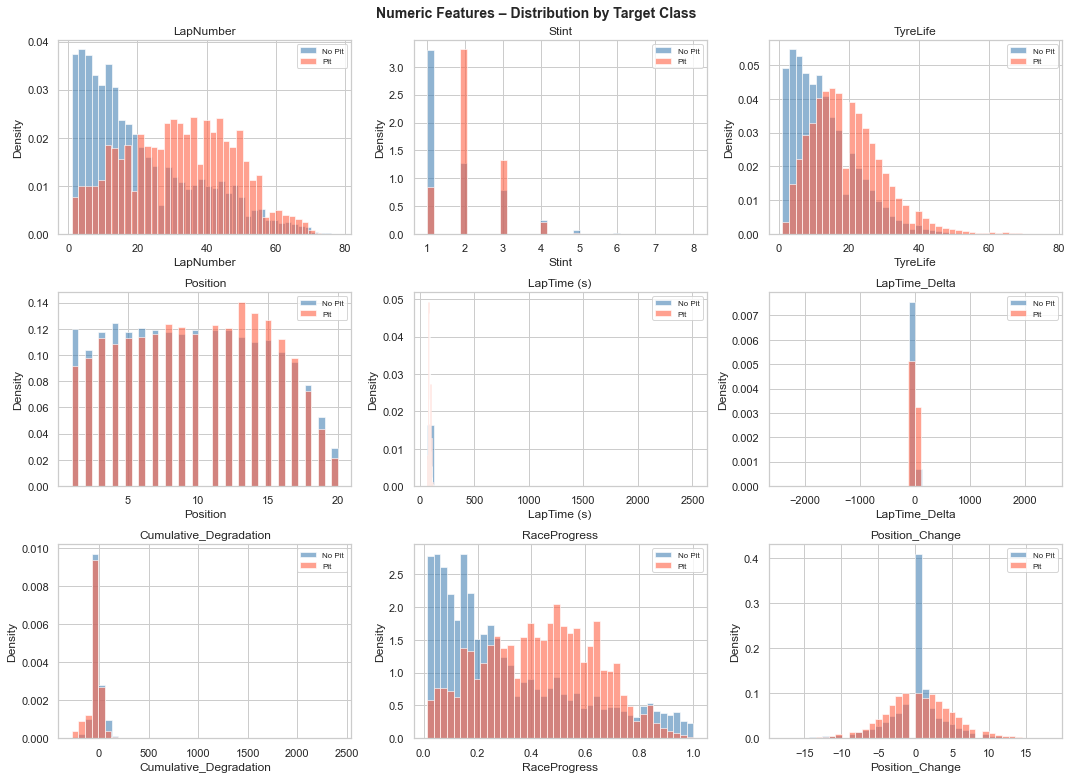

In [8]:
num_cols = ["LapNumber", "Stint", "TyreLife", "Position",
            "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation",
            "RaceProgress", "Position_Change"]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train.loc[train["PitNextLap"] == 0, col].dropna(),
                 bins=40, alpha=0.6, color="steelblue", label="No Pit", density=True)
    axes[i].hist(train.loc[train["PitNextLap"] == 1, col].dropna(),
                 bins=40, alpha=0.6, color="tomato", label="Pit", density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

plt.suptitle("Numeric Features – Distribution by Target Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

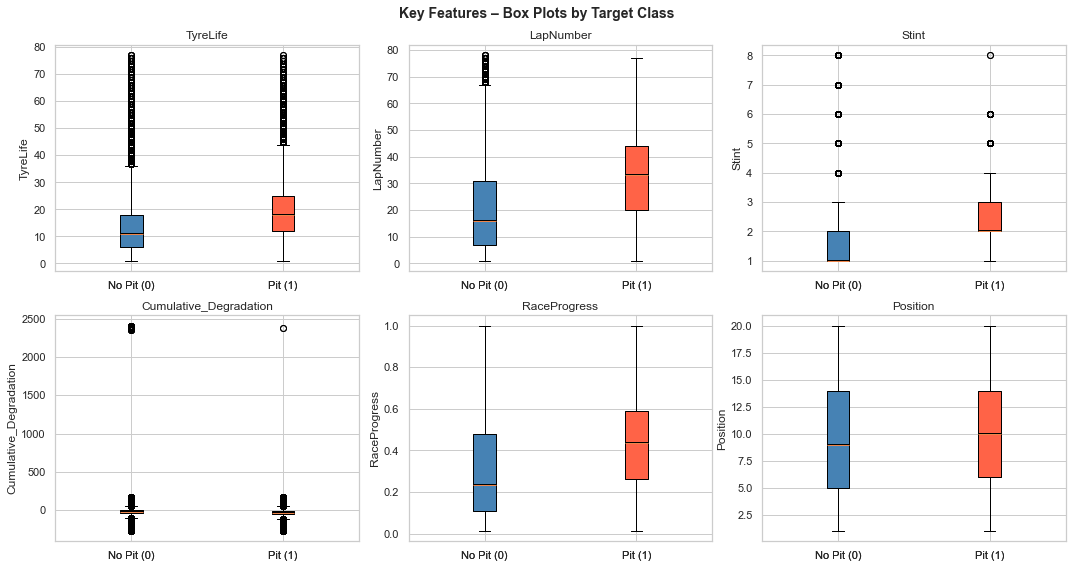

In [9]:
# Box plots of key numeric features vs target
key_cols = ["TyreLife", "LapNumber", "Stint", "Cumulative_Degradation", "RaceProgress", "Position"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    data_no_pit = train.loc[train["PitNextLap"] == 0, col].dropna()
    data_pit    = train.loc[train["PitNextLap"] == 1, col].dropna()
    axes[i].boxplot([data_no_pit, data_pit], labels=["No Pit (0)", "Pit (1)"],
                    patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6),
                    medianprops=dict(color="black", linewidth=2))
    # color the second box differently
    bp = axes[i].boxplot([data_no_pit, data_pit], labels=["No Pit (0)", "Pit (1)"],
                         patch_artist=True)
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("tomato")
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

plt.suptitle("Key Features – Box Plots by Target Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

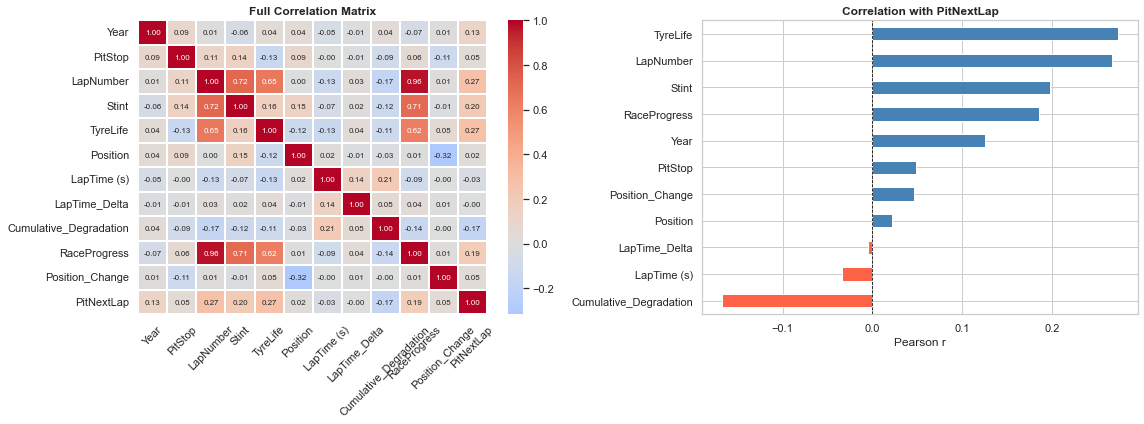

In [10]:
corr = train.select_dtypes(include="number").drop(columns=["id"]).corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.3, ax=axes[0], annot_kws={"size": 8})
axes[0].set_title("Full Correlation Matrix", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

# Correlation with target only
target_corr = corr["PitNextLap"].drop("PitNextLap").sort_values()
colors = ["tomato" if v < 0 else "steelblue" for v in target_corr.values]
target_corr.plot(kind="barh", ax=axes[1], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Correlation with PitNextLap", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

## 6. TyreLife & Degradation Deep-Dive

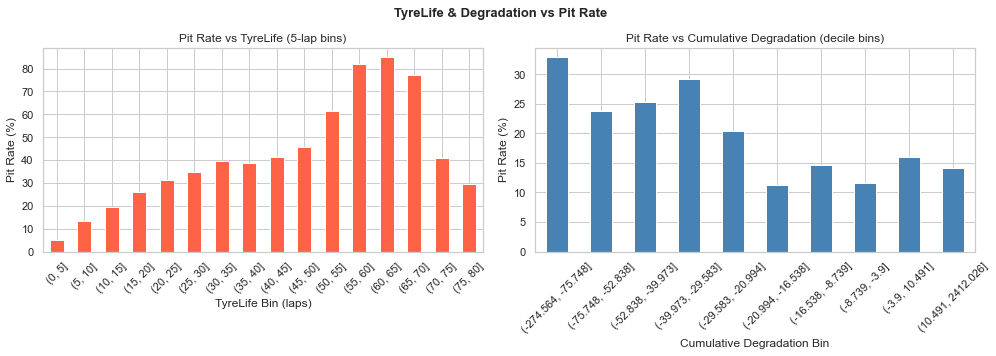

In [11]:
# Pit rate vs TyreLife (binned)
train["TyreLife_bin"] = pd.cut(train["TyreLife"], bins=range(0, 85, 5))
tyre_pit_rate = train.groupby("TyreLife_bin", observed=True)["PitNextLap"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tyre_pit_rate.plot(kind="bar", ax=axes[0], color="tomato", edgecolor="white")
axes[0].set_title("Pit Rate vs TyreLife (5-lap bins)")
axes[0].set_xlabel("TyreLife Bin (laps)")
axes[0].set_ylabel("Pit Rate (%)")
axes[0].tick_params(axis="x", rotation=45)

# Cumulative degradation vs pit rate (binned)
train["Deg_bin"] = pd.cut(train["Cumulative_Degradation"],
                          bins=np.percentile(train["Cumulative_Degradation"].dropna(),
                                             np.arange(0, 110, 10)))
deg_pit_rate = train.groupby("Deg_bin", observed=True)["PitNextLap"].mean() * 100

deg_pit_rate.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Pit Rate vs Cumulative Degradation (decile bins)")
axes[1].set_xlabel("Cumulative Degradation Bin")
axes[1].set_ylabel("Pit Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("TyreLife & Degradation vs Pit Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

train.drop(columns=["TyreLife_bin", "Deg_bin"], inplace=True)

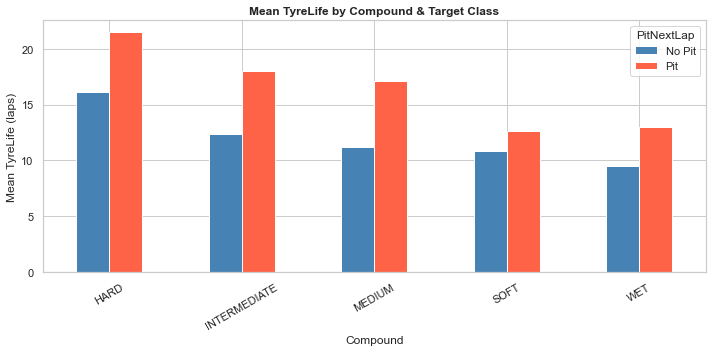

PitNextLap    No Pit   Pit
Compound                  
HARD            16.1  21.5
INTERMEDIATE    12.4  18.0
MEDIUM          11.2  17.1
SOFT            10.8  12.6
WET              9.5  13.0


In [12]:
# Average TyreLife by Compound for pit vs no-pit laps
tyre_by_compound = (
    train.groupby(["Compound", "PitNextLap"])["TyreLife"]
    .mean()
    .unstack()
    .rename(columns={0.0: "No Pit", 1.0: "Pit"})
)

tyre_by_compound.plot(kind="bar", figsize=(10, 5), color=["steelblue", "tomato"],
                      edgecolor="white")
plt.title("Mean TyreLife by Compound & Target Class", fontsize=12, fontweight="bold")
plt.xlabel("Compound")
plt.ylabel("Mean TyreLife (laps)")
plt.xticks(rotation=30)
plt.legend(title="PitNextLap")
plt.tight_layout()
plt.show()

print(tyre_by_compound.round(1))

## 7. Race Progress & Stint Patterns

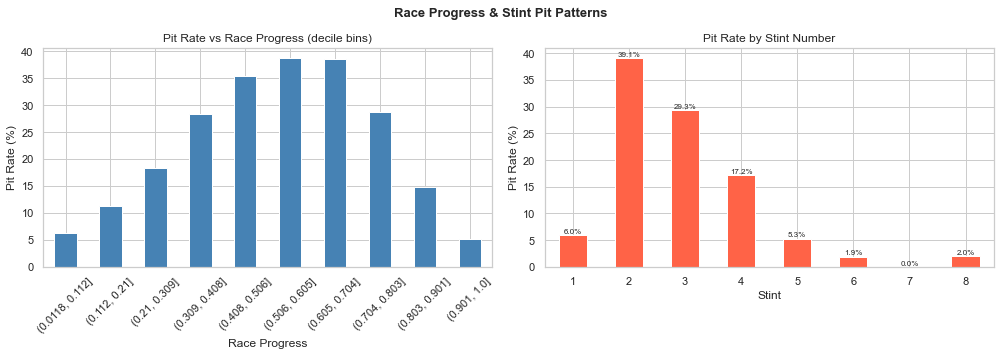

In [13]:
# Pit rate across RaceProgress deciles
train["RP_bin"] = pd.cut(train["RaceProgress"], bins=10)
rp_pit = train.groupby("RP_bin", observed=True)["PitNextLap"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rp_pit.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Pit Rate vs Race Progress (decile bins)")
axes[0].set_xlabel("Race Progress")
axes[0].set_ylabel("Pit Rate (%)")
axes[0].tick_params(axis="x", rotation=45)

# Pit rate by Stint number
stint_pit = train.groupby("Stint")["PitNextLap"].mean() * 100
stint_pit.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("Pit Rate by Stint Number")
axes[1].set_xlabel("Stint")
axes[1].set_ylabel("Pit Rate (%)")
axes[1].tick_params(axis="x", rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                     ha="center", fontsize=8)

plt.suptitle("Race Progress & Stint Pit Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

train.drop(columns=["RP_bin"], inplace=True)

---
## 8. Comparison: `train.csv` vs `f1_strategy_dataset_v4.csv` (Original Dataset)

In [14]:
# ── High-level structural comparison ──────────────────────────────────────────
shared_cols = sorted(set(train.columns) & set(orig.columns))
only_train  = sorted(set(train.columns) - set(orig.columns))
only_orig   = sorted(set(orig.columns)  - set(train.columns))

summary = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Shared Columns",
               "Columns only in train", "Columns only in original",
               "Missing values (train)", "Missing values (original)"],
    "train.csv": [
        f"{len(train):,}", len(train.columns), len(shared_cols),
        str(only_train), "—",
        train.isnull().sum().sum(),
        "—"
    ],
    "f1_strategy_dataset_v4.csv": [
        f"{len(orig):,}", len(orig.columns), len(shared_cols),
        "—", str(only_orig),
        "—",
        orig.isnull().sum().sum()
    ]
})
print(summary.to_string(index=False))

                   Metric train.csv f1_strategy_dataset_v4.csv
                     Rows   439,140                    101,371
                  Columns        16                         16
           Shared Columns        15                         15
    Columns only in train    ['id']                          —
 Columns only in original         —    ['Normalized_TyreLife']
   Missing values (train)         0                          —
Missing values (original)         —                         66


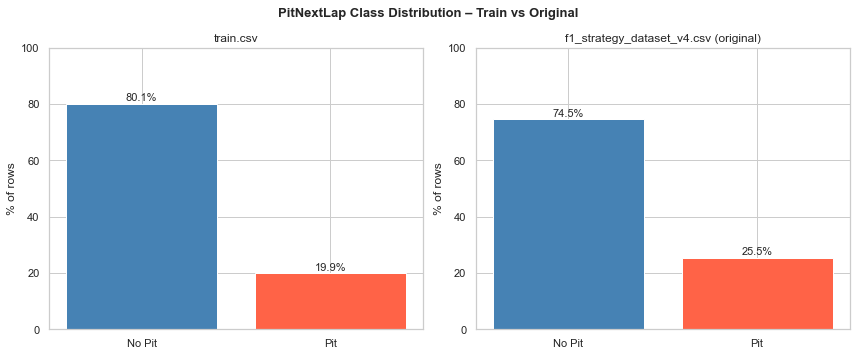

Imbalance ratio train   (0:1) = 4.03
Imbalance ratio original(0:1) = 2.92


In [15]:
# ── Target distribution comparison ────────────────────────────────────────────
train_pct = train["PitNextLap"].value_counts(normalize=True).rename({0.0: "No Pit", 1.0: "Pit"}) * 100
orig_pct  = orig["PitNextLap"].value_counts(normalize=True).rename({0: "No Pit", 1: "Pit"}) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pct, title in zip(axes,
                           [train_pct, orig_pct],
                           ["train.csv", "f1_strategy_dataset_v4.csv (original)"]):
    ax.bar(pct.index, pct.values, color=["steelblue", "tomato"], edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("% of rows")
    ax.set_ylim(0, 100)
    for bar, val in zip(ax.patches, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val:.1f}%", ha="center", fontsize=11)

plt.suptitle("PitNextLap Class Distribution – Train vs Original", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Imbalance ratio train   (0:1) =", round(train["PitNextLap"].value_counts()[0.0] /
                                                train["PitNextLap"].value_counts()[1.0], 2))
print("Imbalance ratio original(0:1) =", round(orig["PitNextLap"].value_counts()[0] /
                                                orig["PitNextLap"].value_counts()[1], 2))

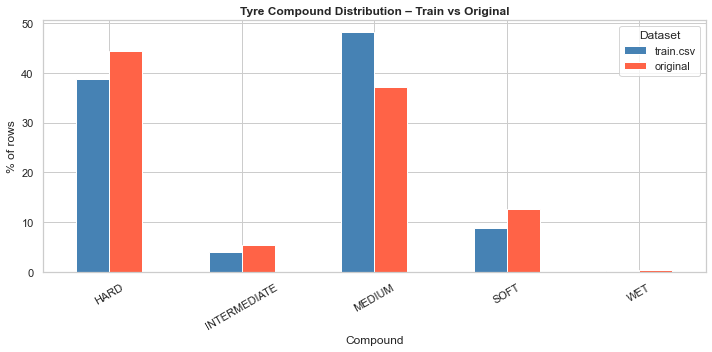

              train.csv  original
HARD              38.83     44.39
INTERMEDIATE       3.96      5.48
MEDIUM            48.08     37.15
SOFT               8.82     12.58
WET                0.31      0.39


In [16]:
# ── Compound distribution comparison ──────────────────────────────────────────
train_comp = train["Compound"].value_counts(normalize=True) * 100
orig_comp  = orig["Compound"].value_counts(normalize=True) * 100

all_compounds = sorted(set(train_comp.index) | set(orig_comp.index))
comp_df = pd.DataFrame({
    "train.csv": [train_comp.get(c, 0) for c in all_compounds],
    "original" : [orig_comp.get(c, 0) for c in all_compounds]
}, index=all_compounds)

ax = comp_df.plot(kind="bar", figsize=(10, 5), color=["steelblue", "tomato"],
                  edgecolor="white")
ax.set_title("Tyre Compound Distribution – Train vs Original", fontsize=12, fontweight="bold")
ax.set_xlabel("Compound")
ax.set_ylabel("% of rows")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Dataset")
plt.tight_layout()
plt.show()

print(comp_df.round(2).to_string())

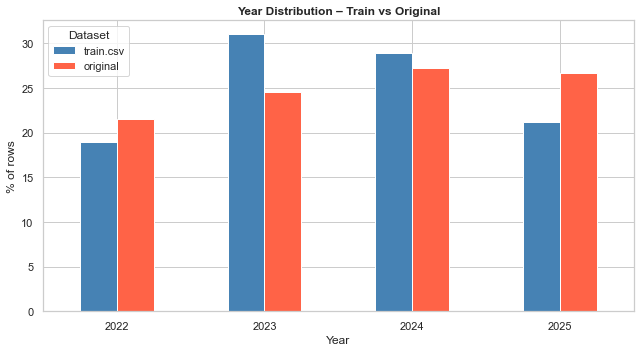

      train.csv  original
2022      18.90     21.56
2023      31.00     24.58
2024      28.95     27.18
2025      21.15     26.67


In [17]:
# ── Year distribution comparison ───────────────────────────────────────────────
train_yr = train["Year"].value_counts(normalize=True).sort_index() * 100
orig_yr  = orig["Year"].value_counts(normalize=True).sort_index() * 100

all_years = sorted(set(train_yr.index) | set(orig_yr.index))
yr_df = pd.DataFrame({
    "train.csv": [train_yr.get(y, 0) for y in all_years],
    "original" : [orig_yr.get(y, 0) for y in all_years]
}, index=all_years)

ax = yr_df.plot(kind="bar", figsize=(9, 5), color=["steelblue", "tomato"],
                edgecolor="white")
ax.set_title("Year Distribution – Train vs Original", fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("% of rows")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Dataset")
plt.tight_layout()
plt.show()

print(yr_df.round(2).to_string())

=== Numeric Feature Statistics Comparison ===
                        train.csv mean  original mean  train.csv std  original std
Year                         2023.5235      2023.5897         1.0249        1.0985
PitStop                         0.1361         0.2516         0.3429        0.4339
LapNumber                      23.1059        30.4448        16.9583       18.1469
Stint                           1.7891         2.0464         0.9502        0.9488
TyreLife                       14.1582        14.5493         9.8013       10.3134
Position                        9.6303         9.7591         5.2788        5.4065
LapTime (s)                    90.9487        92.5872        19.7728       33.2314
LapTime_Delta                  -3.7700        -0.2039        43.9458       45.3449
Cumulative_Degradation        -25.7218       -29.5501        54.7666       70.2358
RaceProgress                    0.3377         0.4326         0.2533        0.2581
Position_Change                 0.1015   

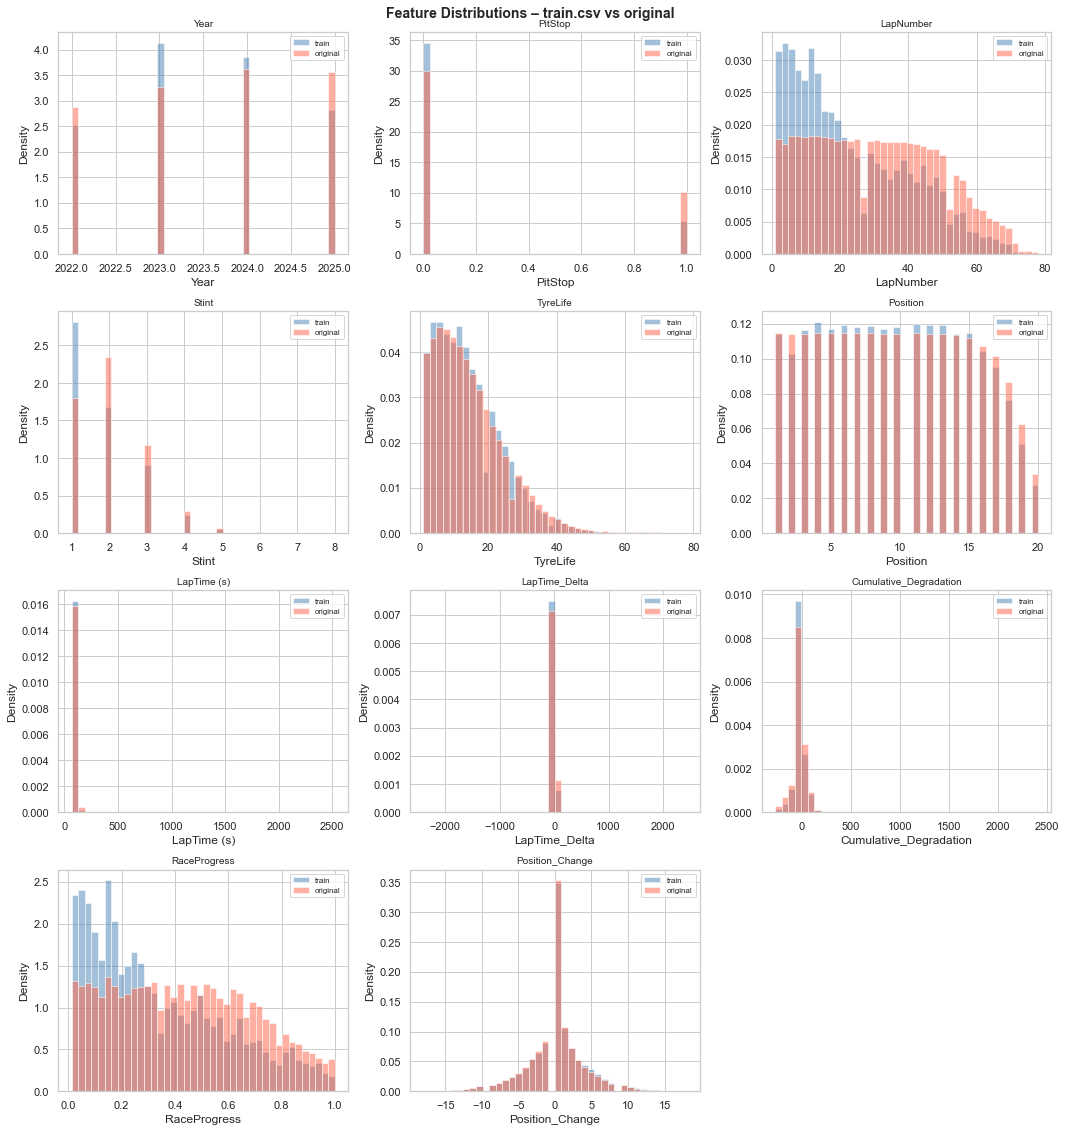

In [19]:
# ── Numeric feature statistics comparison ─────────────────────────────────────
common_num = [c for c in train.select_dtypes("number").columns
              if c in orig.select_dtypes("number").columns
              and c not in ["id", "PitNextLap"]]

stats_train = train[common_num].describe().T[["mean", "std", "min", "max"]]
stats_orig  = orig[common_num].describe().T[["mean", "std", "min", "max"]]

# Side-by-side means
means = pd.DataFrame({
    "train.csv mean" : stats_train["mean"],
    "original mean"  : stats_orig["mean"],
    "train.csv std"  : stats_train["std"],
    "original std"   : stats_orig["std"],
})
print("=== Numeric Feature Statistics Comparison ===")
print(means.round(4).to_string())

n_cols = len(common_num)
n_grid_cols = 3
n_grid_rows = int(np.ceil(n_cols / n_grid_cols))

fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(15, 4 * n_grid_rows))
axes = axes.flatten()

for i, col in enumerate(common_num):
    axes[i].hist(train[col].dropna(), bins=40, alpha=0.5, color="steelblue",
                 label="train", density=True)
    axes[i].hist(orig[col].dropna(),  bins=40, alpha=0.5, color="tomato",
                 label="original", density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

# Hide unused axes
for j in range(n_cols, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions – train.csv vs original", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
# ── Driver coverage comparison ─────────────────────────────────────────────────
print(f"Unique drivers in train.csv   : {train['Driver'].nunique()}")
print(f"Unique drivers in original    : {orig['Driver'].nunique()}")

drivers_train = set(train["Driver"].unique())
drivers_orig  = set(orig["Driver"].unique())

print(f"\nDrivers in original but NOT in train : {sorted(drivers_orig - drivers_train)}")
print(f"Drivers in train but NOT in original : {len(drivers_train - drivers_orig)} "
      f"(train has many historic drivers with encoded IDs)")

# Race coverage
races_train = set(train["Race"].unique())
races_orig  = set(orig["Race"].unique())
print(f"\nUnique races in train.csv : {len(races_train)}")
print(f"Unique races in original  : {len(races_orig)}")
print(f"Races in original not in train: {sorted(races_orig - races_train)}")
print(f"Races in train not in original: {sorted(races_train - races_orig)}")

Unique drivers in train.csv   : 887
Unique drivers in original    : 31

Drivers in original but NOT in train : []
Drivers in train but NOT in original : 856 (train has many historic drivers with encoded IDs)

Unique races in train.csv : 26
Unique races in original  : 28
Races in original not in train: ['Pre-Season Test', 'Pre-Season Track Session']
Races in train not in original: []


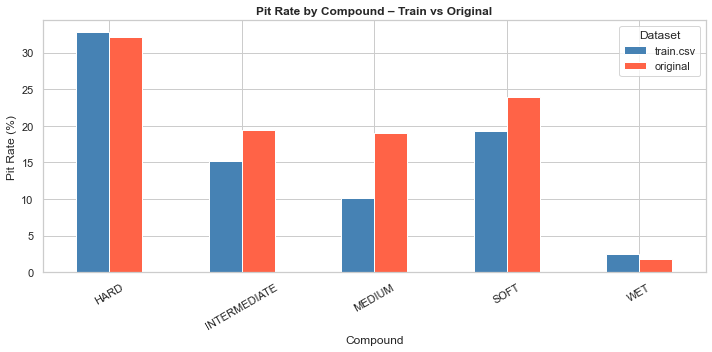

              train.csv  original
HARD              32.75     32.19
INTERMEDIATE      15.23     19.47
MEDIUM            10.11     19.08
SOFT              19.35     23.91
WET                2.51      1.75


In [21]:
# ── Pit rate per Compound comparison ──────────────────────────────────────────
train_cr = train.groupby("Compound")["PitNextLap"].mean() * 100
orig_cr  = orig.groupby("Compound")["PitNextLap"].mean() * 100

all_c = sorted(set(train_cr.index) | set(orig_cr.index))
cr_df = pd.DataFrame({
    "train.csv" : [train_cr.get(c, np.nan) for c in all_c],
    "original"  : [orig_cr.get(c, np.nan)  for c in all_c],
}, index=all_c)

ax = cr_df.plot(kind="bar", figsize=(10, 5), color=["steelblue", "tomato"],
                edgecolor="white")
ax.set_title("Pit Rate by Compound – Train vs Original", fontsize=12, fontweight="bold")
ax.set_xlabel("Compound")
ax.set_ylabel("Pit Rate (%)")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Dataset")
plt.tight_layout()
plt.show()

print(cr_df.round(2).to_string())

### Key Differences Summary

| Aspect | `train.csv` | `f1_strategy_dataset_v4.csv` |
|---|---|---|
| **Rows** | 439,140 | 101,371 |
| **Drivers** | 887 (encoded IDs — includes historical F1 data) | 31 (real driver codes, recent seasons only) |
| **Unique Races** | 26 | 28 |
| **Class imbalance (0:1)** | ~4.0x | ~2.9x |
| **Compound majority** | MEDIUM (48%) | HARD (44%) |
| **Extra column in train** | `id` | — |
| **Extra column in original** | — | `Normalized_TyreLife` |
| **Missing values** | 0 | 66 (Compound) |
| **Years covered** | 2022–2025 | 2022–2025 |

> `train.csv` is a heavily augmented version of the original dataset. It contains ~4.3× more rows, includes many more historical drivers with anonymised IDs, has a more severe class imbalance (∼80/20 vs ∼75/25), and already drops `Normalized_TyreLife` while adding a row `id` column.